## Sección 0 – Setup
- Carga del dataset congelado (`df_entrenamiento_v1.csv`)
- Verificación de dimensiones y columnas

In [1]:
import pandas as pd
from pathlib import Path

# Ruta al dataset congelado (ajustar nombre si es necesario)
freeze_folder = Path('..') / 'freeze'
csv_files = sorted(freeze_folder.glob('df_entrenamiento_v1_*.csv'))
assert csv_files, 'No se encontró archivo df_entrenamiento_v1_*.csv en freeze/'
data_path = csv_files[-1]  # Usar el más reciente
df = pd.read_csv(data_path)
print(f'Dataset cargado: {data_path}')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print('Columnas:', list(df.columns))

Dataset cargado: ..\freeze\df_entrenamiento_v1_20251228_200900.csv
Dimensiones: 16161 filas x 18 columnas
Columnas: ['date', 'prueba_de_produccion_petróleo_a_24_horas_bbld', 'prueba_de_producción_gas_a_24_horas_mcfd', 'bsw_pct', 'gravedad_api_del_petroleo', 'salinidad_ppm_pu', 'presion_de_intake_psi', 'frecuencia_bomba_hz', 'amperaje_bomba_amp', 'presion_de_tubing_psi', 'presion_de_casing_psi', 'temperatura_de_la_bomba_deg_f', 'etapas_de_la_bomba', 'delta_1', 'slope_7', 'slope_14', 'ratio14', 'pred_evento']


## Sección 1 – Distribución de la variable objetivo
Objetivo: verificar estabilidad y desbalance.
- Conteo de `pred_evento` global
- Conteo por año
- Conteo por pozo

⚠️ Busca: clases inexistentes en ciertos años, pozos con una sola clase.

In [3]:


# Asegurar que la columna de fecha esté en datetime
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['year'] = df['date'].dt.year

# --------------------------------------------------
# Conteo global de la variable objetivo
# --------------------------------------------------
print("Conteo global de pred_evento:")
print(df['pred_evento'].value_counts(dropna=False))

# --------------------------------------------------
# Conteo de pred_evento por año
# --------------------------------------------------
if 'year' in df.columns:
    print("\nConteo de pred_evento por año:")
    conteo_anio = (
        df.groupby('year')['pred_evento']
          .value_counts(dropna=False)
          .unstack(fill_value=0)
          .sort_index()
    )
    print(conteo_anio)

# --------------------------------------------------
# Conteo de pred_evento por pozo
# --------------------------------------------------
if 'name_' in df.columns:
    print("\nConteo de pred_evento por pozo:")
    conteo_pozo = (
        df.groupby('name_')['pred_evento']
          .value_counts(dropna=False)
          .unstack(fill_value=0)
    )
    print(conteo_pozo)

    # Identificar pozos con una sola clase
    single_class_wells = (
        df.groupby('name_')['pred_evento']
          .nunique(dropna=True) == 1
    )

    if single_class_wells.any():
        print("\nPozos con una sola clase en pred_evento:")
        print(single_class_wells[single_class_wells].index.tolist())
    else:
        print("\nNo se detectaron pozos con una sola clase.")


Conteo global de pred_evento:
pred_evento
0    12511
1     1963
2     1687
Name: count, dtype: int64

Conteo de pred_evento por año:
pred_evento     0    1    2
year                       
2012            1    0    0
2015          814   89   51
2016          835  122   72
2017          718  185  152
2018         1146  249  197
2019         1440  176  166
2020         1355  161  113
2021         1315  156  183
2022         1234  123  103
2023         1180  279  233
2024         1360  206  201
2025         1113  217  216


## Sección 2 – Missingness temporal
Objetivo: confirmar que los NaN son estructurales y no hay patrones anómalos post-filtrado.
- Porcentaje de NaN por variable
- Heatmap de NaN por año
- Comparación 2015–2017 vs 2018–2025

Porcentaje de NaN por variable:
presion_de_casing_psi                            68.133160
temperatura_de_la_bomba_deg_f                    40.746241
presion_de_intake_psi                            32.256667
amperaje_bomba_amp                               17.876369
frecuencia_bomba_hz                              17.158592
salinidad_ppm_pu                                 14.485490
etapas_de_la_bomba                               12.505414
ratio14                                           3.978714
slope_14                                          1.138543
slope_7                                           0.569272
gravedad_api_del_petroleo                         0.402203
delta_1                                           0.284636
presion_de_tubing_psi                             0.235134
bsw_pct                                           0.030939
date                                              0.000000
prueba_de_producción_gas_a_24_horas_mcfd          0.000000
prueba_de_produccion_pet

C:\Users\Vìctor\AppData\Local\Temp\ipykernel_12492\1052369760.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year = df.groupby('year').apply(lambda x: x.isnull().mean() * 100)


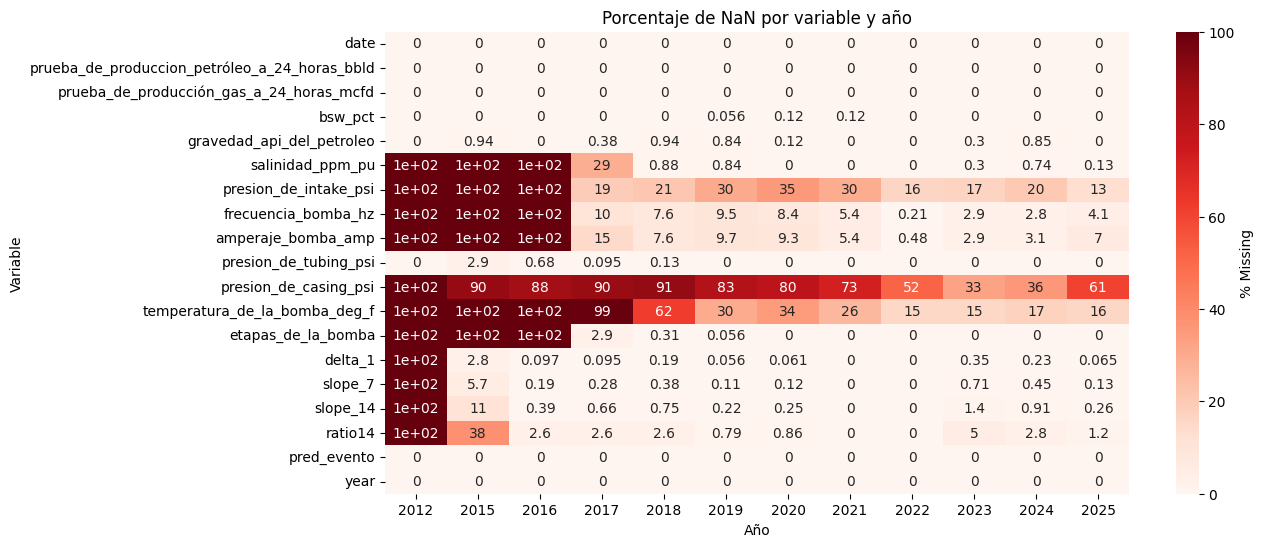

Comparación de missingness: 2015–2017 vs 2018–2025
2015–2017:
date                                              0.000000
prueba_de_produccion_petróleo_a_24_horas_bbld     0.000000
prueba_de_producción_gas_a_24_horas_mcfd          0.000000
bsw_pct                                           0.000000
gravedad_api_del_petroleo                         0.427913
salinidad_ppm_pu                                 75.411455
presion_de_intake_psi                            71.922317
frecuencia_bomba_hz                              68.762344
amperaje_bomba_amp                               70.309414
presion_de_tubing_psi                             1.184990
presion_de_casing_psi                            89.203423
temperatura_de_la_bomba_deg_f                    99.802502
etapas_de_la_bomba                               66.293614
delta_1                                           0.954575
slope_7                                           1.942067
slope_14                                          3.9

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Porcentaje de NaN por variable
missing_pct = df.isnull().mean() * 100
print('Porcentaje de NaN por variable:')
print(missing_pct.sort_values(ascending=False))

# Heatmap de NaN por año
if 'year' in df.columns:
    missing_by_year = df.groupby('year').apply(lambda x: x.isnull().mean() * 100)
    plt.figure(figsize=(12, 6))
    sns.heatmap(missing_by_year.T, annot=True, cmap='Reds', cbar_kws={'label': '% Missing'})
    plt.title('Porcentaje de NaN por variable y año')
    plt.ylabel('Variable')
    plt.xlabel('Año')
    plt.show()
    # Comparación 2015–2017 vs 2018–2025
    mask_early = df['year'].between(2015, 2017)
    mask_late = df['year'].between(2018, 2025)
    print('Comparación de missingness: 2015–2017 vs 2018–2025')
    print('2015–2017:')
    print(df[mask_early].isnull().mean() * 100)
    print('2018–2025:')
    print(df[mask_late].isnull().mean() * 100)

## Sección 3 – Confirmación de no-leakage
Objetivo: demostrar formalmente que no quedan variables del sistema de etiquetado.
- Revisar que no existan columnas como `env_q`, `env_gate`, `evento_hibrido`, `confirm`, `alarma_instantanea`, `persist`, `persist_ref`, `regimen_id`, `fuera_inst`, `enough`
- Mostrar advertencia si alguna está presente

In [5]:
# Lista de posibles variables de fuga
leakage_vars = [
    'env_q', 'env_gate', 'evento_hibrido', 'confirm', 'alarma_instantanea',
    'persist', 'persist_ref', 'regimen_id', 'fuera_inst', 'enough'
]
present_leakage = [v for v in leakage_vars if v in df.columns]
if present_leakage:
    print('Variables de leakage presentes en el dataset:', present_leakage)
else:
    print('No se detectaron variables de leakage en el dataset.')

No se detectaron variables de leakage en el dataset.


Eliminación de presion_de_casing_psi: La razòn es porque desde el 2018-2022 hay alrededor de 80% de datos ausentes, y desde 2022-2025 alrededor de 60% de datos ausentes.

In [6]:

if 'presion_de_casing_psi' in df.columns:
    df = df.drop(columns=['presion_de_casing_psi'])
    print('Columna presion_de_casing_psi eliminada.')
else:
    print('La columna presion_de_casing_psi no está presente en el DataFrame.')

Columna presion_de_casing_psi eliminada.
